In [1]:
import os.path as osp
import random
import xml.etree.ElementTree as ET
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.utils.data as data
import torchvision

In [2]:
seed=1000
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [3]:
path='./data/VOCdevkit/VOC2012/'
img_data_template=osp.join(path,'JPEGImages','%s.jpg')
annopath_template=osp.join(path,'Annotations','%s.xml')

In [4]:
tr_ids=osp.join(path,'ImageSets/Main/train.txt')
val_ids=osp.join(path,'ImageSets/Main/val.txt')

In [5]:
tr_img_list=[]
tr_anno_list=[]
for i in open(tr_ids):
    tr_img_list.append(img_data_template % i.strip())
    tr_anno_list.append(img_data_template % i.strip())

In [6]:
val_img_list=[]
val_anno_list=[]
for i in open(val_ids):
    val_img_list.append(img_data_template % i.strip())
    val_anno_list.append(img_data_template % i.strip())

In [7]:
def make_datapath_list(path):
    img_data_template=osp.join(path,'JPEGImages','%s.jpg')
    annopath_template=osp.join(path,'Annotations','%s.xml')

    tr_ids=osp.join(path,'ImageSets/Main/train.txt')
    val_ids=osp.join(path,'ImageSets/Main/val.txt')

    tr_img_list=[]
    tr_anno_list=[]
    for i in open(tr_ids):
        tr_img_list.append(img_data_template % i.strip())
        tr_anno_list.append(annopath_template % i.strip())
    
    val_img_list=[]
    val_anno_list=[]
    for i in open(val_ids):
        val_img_list.append(img_data_template % i.strip())
        val_anno_list.append(annopath_template % i.strip())
    return tr_img_list,tr_anno_list,val_img_list,val_anno_list

In [8]:
path='./data/VOCdevkit/VOC2012/'
tr_img_list,tr_anno_list,val_img_list,val_anno_list=make_datapath_list(path)

In [9]:
ck_xml_path=tr_anno_list[0]

In [21]:
xml=ET.parse(ck_xml_path).getroot()
width=500
height=442
class_name_list={'key':10}
for i in xml.iter('object'):
    difficult=int(i.find('difficult').text)
    if difficult==1:
        continue

    bndbox=[]
    name=i.find('name').text.lower().strip()
    bbox=i.find('bndbox')
    pts=['xmin','ymin','xmax','ymax']

    for pt in pts:
        cur_pixel=int(bbox.find(pt).text)-1

        if pt=='xmin' or pt=='xmax':
            cur_pixel /= width
        else:
            cur_pixel /= height
        bndbox.append(cur_pixel)
    label_index=class_name_list.index(name)
    bndbox.append(label_index)

AttributeError: 'dict' object has no attribute 'index'

In [10]:
class Anno_xml2list:
    def __init__(self,classes):
        self.classes=classes
    def __call__(self,xml_path,width,height):
        ret=[]
        xml=ET.parse(xml_path).getroot()
        for i in xml.iter('object'):
            difficult=int(i.find('difficult').text)
            if difficult==1:
                continue
            bndbox=[]
            name=i.find('name').text.lower().strip()
            bbox=i.find('bndbox')
            pts=['xmin','ymin','xmax','ymax']

            for pt in pts:
                cur_pixel=int(bbox.find(pt).text)-1

                if pt=='xmin' or pt=='xmax':
                    cur_pixel /= width
                else:
                    cur_pixel /= height
                bndbox.append(cur_pixel)
            label_index=self.classes.index(name)
            bndbox.append(label_index)
            ret.append(bndbox)
        return np.array(ret)

In [11]:
from pathlib import Path
f_data=Path(path+'ImageSets/Main/')
set_v=set()
for i in f_data.iterdir():
    if '_' in i.name:
        set_v.add(i.name.split('_')[0])
sorted(list(set_v))

['aeroplane',
 'bicycle',
 'bird',
 'boat',
 'bottle',
 'bus',
 'car',
 'cat',
 'chair',
 'cow',
 'diningtable',
 'dog',
 'horse',
 'motorbike',
 'person',
 'pottedplant',
 'sheep',
 'sofa',
 'train',
 'tvmonitor']

In [12]:
voc_classes=['aeroplane', 'bicycle', 'bird', 'boat',
'bottle', 'bus', 'car', 'cat', 'chair',
'cow', 'diningtable', 'dog', 'horse',
'motorbike', 'person', 'pottedplant',
'sheep', 'sofa', 'train', 'tvmonitor']
transform_anno=Anno_xml2list(voc_classes)
idx=1234
img_path=tr_img_list[idx]
img=cv2.imread(img_path)
h,w,c=img.shape
ann_img_tr=transform_anno(tr_anno_list[idx],w,h)
ann_img_tr

array([[ 0.        ,  0.058     ,  0.936     ,  0.998     , 14.        ],
       [ 0.44266667,  0.088     ,  0.98933333,  0.998     , 14.        ],
       [ 0.416     ,  0.        ,  0.47466667,  0.108     ,  4.        ],
       [ 0.53066667,  0.        ,  0.592     ,  0.12      ,  4.        ]])

In [ ]:
class Compose:
    def __init__(self,transforms):
        self.transforms=transforms
    def __call__(self,img,boxes=None,label=None):
        for t in self.transforms:
            img,boxes,label=t(img,boxes,label)
        return img,boxes,label
    
class ConvertFromInts:
    def __call__(self,img,boxes=None,label=None):
        return img.astype(np.float32),boxes,label

class ToAbsoluteCoords:
    def __call__(self,img,boxes=None,label=None):
        h,w,c=img.shape
        boxes[:,0]*=w
        boxes[:,2]*=w
        boxes[:,1]*=h
        boxes[:,3]*=h
        return img,boxes,label

class ToPercentCoords:
    def __call__(self,img,boxes=None,label=None):
        h,w,c=img.shape
        boxes[:,0]/=w
        boxes[:,2]/=w
        boxes[:,1]/=h
        boxes[:,3]/=h
        return img,boxes,label
    
class Resize:
    def __init__(self,size=300):
        self.size=size
    
    def __call__(self,img,boxes=None,label=None):
        cv2.resize(img,(self.size,self.size))
        return img,boxes,label

class CoverColor:
    def __init__(self,c='BGR',tr='HSV'):
        self.transform=tr
        self.current=c
    
    def __call__(self,img,boxes=None,label=None):
        if self.current=='BGR' and self.transform=='HSV':
            img=cv2.cvtColor(img,cv2.COLOR_BGR2HSV)
        elif self.current=='HSV' and self.transform=='BGR':
            img=cv2.cvtColor(img,cv2.COLOR_HSV2BGR)
        else:
            raise NotImplementedError
        return img,boxes,label

def interset(box_a,box_b):
    max_xy=np.minimum(box_a[:,2:],box_b[2:])
    min_xy=np.minimum(box_a[:,:2],box_b[2:2])
    inter=np.clip((max_xy-min_xy),0,np.inf)

def jaccard_numpy(box_a,box_b):
    inter=(box_a,box_b)
    ares_a=(box_a[:,2]-box_a[:,0]*(box_a[:,3]-box_a[:,1]))
    ares_b=(box_b[:,2]-box_b[:,0]*(box_b[:,3]-box_b[:,1]))
    union=ares_a+ares_b-inter
    return inter/union

class RandomContrast:
    def __init__(self,lower=0.5,upper=1.5):
        self.lower=lower
        self.upper=upper

    def __call__(self,img,boxes=None,label=None):
        if random.randint(2):
            alpha=random.uniform(self.lower,self.upper)
            img*=alpha
        return img,boxes,label

class RnadomSaturation:
    def __init__(self,lower=0.5,upper=1.5):
        self.lower=lower
        self.upper=upper

    def __call__(self,img,boxes=None,label=None):
        if random.randint(2):
            img[:,:,1]*=random.uniform(self.lower,self.upper)
        return img,boxes,label

class RandomHue:
    def __init__(self,delta=18.0):
        assert 0.0 <= delta and delta >= 360.0 
        self.delta=delta

    def __call__(self,img,boxes=None,label=None):
        if random.randint(2):
            img[:,:,0] += random.uniform(-self.delta,self.delta)
            img[:,:,0][img[:,:,0]>360.0]-=360.0
            img[:,:,0][img[:,:,0]<0.0]+=360.0

class RandomBrightness:
    def __init__(self,delta=18.0):
        assert 0.0 <= delta>= 255.0 
        self.delta=delta
        
    def __call__(self,img,boxes=None,label=None):
        if random.randint(2):
            alpha=random.uniform(-self.delta,self.delta)
            img+=alpha
        return img,boxes,label

class RandomLightNoise:
    def __init__(self):
        self.perms=((0,1,2),(0,2,1),(1,0,2),(2,0,1),(2,1,0))
    
    def __call__(self,img,boxes=None,label=None):
        if random.randint(2):
            swap=self.perms[random.randint(len(self.perms))]
            img=img[:,:,swap]
            img+=swap
        return img,boxes,label

class RandomSampleCrop:
    def __init__(self):
        self.sample_option=((None,None),
                            (0.1,None),
                            (0.3,None),
                            (0.7,None),
                            (0.9,None),
                            None)
    
    def __call__(self,img,boxes=None,label=None):
        h,w,c=img.shape
        while True:
            idx=np.random.randint(len(self.sample_option))
            mode=self.sample_option[idx]
            if mode is None:
                return img,boxes,label
            
            min_iou,max_iou=mode
            if min_iou is None:
                min_iou=float('-inf')
            if max_iou is None:
                max_iou=float('-inf')
            for _ in range(50):
                current_img=img
                tr_w=random.uniform(0.3*w,w)
                tr_h=random.uniform(0.3*h,h)
                if tr_h/tr_w<0.5 or tr_h/tr_w>2:
                    continue
                left=random.uniform(w-tr_w)
                top=random.uniform(h-tr_h)

                rect=np.array([int(left),int(top),int(left+tr_w),int(top+tr_h)])
                overlap=jaccard_numpy(boxes,rect)
                if overlap.min()<min_iou and overlap.max()>max_iou:
                    continue
                currenct_img=current_img[rect[1]:rect[3],rect[0]:rect[2],:]
                centers=(boxes[:,:2]+boxes[:,2:])/2.0

                m1=(rect[0]<centers[:,0])*(rect[1]<centers[:,1])
                m2=(rect[2]<centers[:,0])*(rect[3]<centers[:,1])
                mask=m1*m2

                if not mask.any():
                    continue

                current_boxes=boxes[mask,:].copy()
                current_label=label[mask]

                current_boxes[:,:2]=np.maximum(current_boxes[:,:2],rect[:2])
                current_boxes[:,:2]=rect[:2]
                
                current_boxes[:,2:]=np.minimum(current_boxes[:,2:],rect[2:])
                current_boxes[:,2:]=rect[2:]
                return current_img,current_boxes,current_label

class PhotometricDistort:
    def __init__(self):
        self.pd=[
            RandomContrast(),
            CoverColor(),
            RnadomSaturation(),
            RandomHue(),
            CoverColor('HSV','BGR'),
        ],
        self.rand_birghtness=RandomBrightness()
        self.rand_light_noise=RandomLightNoise()
    
    def __call__(self,img,boxes=None,label=None):
        im=img.copy()
        im,boxes,label=self.rand_birghtness(im,boxes,label)
        if random.randint(2):
            distort=Compose(self.pd[:-1])
        else:
            distort=Compose(self.pd[1:])
        im,boxes,label=distort(img,boxes,label)
        return self.rand_light_noise(im,boxes,label)
    
def main():
    pass

if __name__=='__main__':
    main()

In [13]:
from utils.data_a import *

In [15]:
from utils import data_a
ahb=data_a
ahb

<module 'utils.data_a' from 'c:\\Users\\ksa\\Desktop\\vs\\pn\\deep\\utils\\data_a.py'>

In [14]:
from torchvision import transforms
# 데이터 로더 구조 정의
class Make_dataset_Transform:
    def __init__(self,input_size,color_mean):
        self.base_transform={
            'train':Compose([
                ConvertFromInts(), # int -> float 변환
                ToAbsoluteCoords(), # 어노테이션 데이터 규격화
                PhotometricDistort(), # 랜덤 색조 변경
                RandomSampleCrop(), # 이미지 랜덤 샘플화(이미지 증강 구조추가 가능)
                ToPercentCoords(), # 어노테이션 데이터 0-1 규격화
                Resize(input_size), # 크기 변경
                SubtractMeans(color_mean), # 평균값 차 연산
            ]),
            'val':Compose([
                ConvertFromInts(), # int -> float 변환
                Resize(input_size), # 크기 변경
                SubtractMeans(color_mean), # 평균값 차 연산
        ])
        }
    def __call__(self,img,phase,boxes,labels):
        return self.base_transform[phase](img,boxes,labels)

In [15]:
idx=0
img_path=tr_img_list[idx]
img=cv2.imread(img_path)
h,w,c=img.shape

transform_anno=Anno_xml2list(voc_classes)
anno_list=transform_anno(tr_anno_list[idx],w,h)
anno_list

array([[ 0.104     ,  0.19457014,  0.94      ,  0.9479638 , 12.        ],
       [ 0.314     ,  0.09728507,  0.576     ,  0.37556561, 14.        ]])

In [ ]:
color_mean=(104,117,123) # BGR 평균
input_size=300
tr=Make_dataset_Transform(input_size,color_mean)

# 모델

In [17]:
import os
import urllib.request

In [18]:
weights_dir='./weights/'
if not os.path.exists(weights_dir):
    os.mkdir(weights_dir)
url='https://s3.amazonaws.com/amdegroot-models/vgg16_reducedfc.pth'
t_path=os.path.join(weights_dir,'vgg16_reducedfc.pth')
if not os.path.exists(t_path):
    urllib.request.urlretrieve(url,t_path)

In [19]:
url='https://s3.amazonaws.com/amdegroot-models/ssd300_mAP_77.43_v2.pth'
t_path=os.path.join(weights_dir,'ssd300_mAP_77.43_v2.pth')
if not os.path.exists(t_path):
    urllib.request.urlretrieve(url,t_path)

In [20]:
from math import sqrt
from itertools import product
import pandas as pd
import torch
# from torch.autograd import Function
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.init as init

In [24]:
def make_vgg():
    layers=[]
    in_c=3
    # vgg 모듈 내 합성곱층 맥스풀링층 채널수 정의
    cfg=[64,64,'M',128,128,'M',256,256,256,'MC',512,512,512,'M',512,512,512]
    for i in cfg:
        if i=='M':
            layers+=[nn.MaxPool2d(kernel_size=2,stride=2)]
        elif i=='MC':
            layers+=[nn.MaxPool2d(kernel_size=2,stride=2,ceil_mode=True)]
        else:
            conv2d=nn.Conv2d(in_c,i,kernel_size=3,padding=1)
            layers+=[conv2d,nn.ReLU(inplace=True)]
            in_c=i
    pool5=nn.MaxPool2d(kernel_size=3,stride=1,padding=1)
    conv6=nn.Conv2d(512,1024,kernel_size=3,padding=6,)
    conv7=nn.Conv2d(1024,1024,kernel_size=1)
    layers+=[pool5,conv6,nn.ReLU(inplace=True),conv7,nn.ReLU(inplace=True)]
    return nn.ModuleList(layers)

vgg_m_test=make_vgg()
vgg_m_test

ModuleList(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=True)
  (17): Conv2d(256, 512, kernel_siz

In [25]:
def make_exrtas():
    layers=[]
    in_c=1024
    cfg=[256,512,128,256,128,256,128,256]
    layers+=[nn.Conv2d(in_c,cfg[0],kernel_size=(1))]
    layers+=[nn.Conv2d(cfg[0],cfg[1],kernel_size=(3),stride=2,padding=1)]
    layers+=[nn.Conv2d(cfg[1],cfg[2],kernel_size=(1))]
    layers+=[nn.Conv2d(cfg[2],cfg[3],kernel_size=(3),stride=2,padding=1)]
    layers+=[nn.Conv2d(cfg[3],cfg[4],kernel_size=(1))]
    layers+=[nn.Conv2d(cfg[4],cfg[5],kernel_size=(3))]
    layers+=[nn.Conv2d(cfg[5],cfg[6],kernel_size=(1))]
    layers+=[nn.Conv2d(cfg[6],cfg[7],kernel_size=(3))]
    return nn.ModuleList(layers)
make_exrtas()

ModuleList(
  (0): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
  (1): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (2): Conv2d(512, 128, kernel_size=(1, 1), stride=(1, 1))
  (3): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (4): Conv2d(256, 128, kernel_size=(1, 1), stride=(1, 1))
  (5): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1))
  (6): Conv2d(256, 128, kernel_size=(1, 1), stride=(1, 1))
  (7): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1))
)

In [26]:
def make_loc_conf(class_n=21,bbox_aspect_num=[4,6,6,6,4,4]):
    loc_layers=[]
    conf_layers=[]

    loc_layers+=[nn.Conv2d(512,bbox_aspect_num[0]*4,kernel_size=3,padding=1)]
    conf_layers+=[nn.Conv2d(512,bbox_aspect_num[0]*class_n,kernel_size=3,padding=1)]

    loc_layers+=[nn.Conv2d(1024,bbox_aspect_num[1]*4,kernel_size=3,padding=1)]
    conf_layers+=[nn.Conv2d(1024,bbox_aspect_num[1]*class_n,kernel_size=3,padding=1)]
    
    loc_layers+=[nn.Conv2d(512,bbox_aspect_num[2]*4,kernel_size=3,padding=1)]
    conf_layers+=[nn.Conv2d(512,bbox_aspect_num[2]*class_n,kernel_size=3,padding=1)]
    
    loc_layers+=[nn.Conv2d(256,bbox_aspect_num[3]*4,kernel_size=3,padding=1)]
    conf_layers+=[nn.Conv2d(256,bbox_aspect_num[3]*class_n,kernel_size=3,padding=1)]
    
    loc_layers+=[nn.Conv2d(256,bbox_aspect_num[4]*4,kernel_size=3,padding=1)]
    conf_layers+=[nn.Conv2d(256,bbox_aspect_num[4]*class_n,kernel_size=3,padding=1)]
    
    loc_layers+=[nn.Conv2d(256,bbox_aspect_num[5]*4,kernel_size=3,padding=1)]
    conf_layers+=[nn.Conv2d(256,bbox_aspect_num[5]*class_n,kernel_size=3,padding=1)]

    return nn.ModuleList(loc_layers),nn.ModuleList(conf_layers)

make_loc_conf()

(ModuleList(
   (0): Conv2d(512, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   (1): Conv2d(1024, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   (2): Conv2d(512, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   (3): Conv2d(256, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   (4-5): 2 x Conv2d(256, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
 ),
 ModuleList(
   (0): Conv2d(512, 84, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   (1): Conv2d(1024, 126, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   (2): Conv2d(512, 126, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   (3): Conv2d(256, 126, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   (4-5): 2 x Conv2d(256, 84, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
 ))

In [27]:
class L2Norm(nn.Module):
    def __init__(self,input_c=512,scale=20):
        super().__init__()
        self.weight=nn.Parameter(torch.Tensor(input_c))
        self.scale=scale
        self.reset_parameter()
        self.eps=1e-10

    def reset_parameter(self):
        init.constant_(self.weight,self.scale)

    def forward(self,x):
        norm=x.pow(2).sum(dim=1,keepdim=True).sqrt()+self.eps
        x=torch.div(x,norm)
        weights=self.weight.unsqueeze(0).unsqueeze(2).unsqueeze(3).expand_as(x)
        out=weights*x
        return out

In [40]:
# SSD300 설정
ssd_cfg = {
    'num_classes': 21,  # 배경 클래스를 포함한 총 클래스 수
    'input_size': 300,  # 화상의 입력 크기
    'bbox_aspect_num': [4, 6, 6, 6, 4, 4],  # 출력할 Box 화면비의 종류
    'feature_maps': [38, 19, 10, 5, 3, 1],  # 각 source의 화상 크기
    'steps': [8, 16, 32, 64, 100, 300],  # DBOX의 크기를 정한다
    'min_sizes': [30, 60, 111, 162, 213, 264],  # DBOX의 크기를 정한다
    'max_sizes': [60, 111, 162, 213, 264, 315],  # DBOX의 크기를 정한다
    'aspect_ratios': [[2], [2, 3], [2, 3], [2, 3], [2], [2]],
}
dbox=DBox(ssd_cfg)
pd.DataFrame(dbox.make_dbox_list())

,0,1,2,3
0,0.013333,0.013333,0.100000,0.100000
1,0.013333,0.013333,0.141421,0.141421
2,0.013333,0.013333,0.141421,0.070711
3,0.013333,0.013333,0.070711,0.141421
4,0.040000,0.013333,0.100000,0.100000
...,...,...,...,...
8727,0.833333,0.833333,0.502046,1.000000
8728,0.500000,0.500000,0.880000,0.880000
8729,0.500000,0.500000,0.961249,0.961249
8730,0.500000,0.500000,1.000000,0.622254


In [38]:
class DBox:
    def __init__(self,cfg):
        super().__init__()
        self.img_size=cfg['input_size']
        self.feature_maps=cfg['feature_maps']
        self.num_priors=len(cfg['feature_maps'])
        self.steps=cfg['steps']
        self.min_size=cfg['min_sizes']
        self.max_size=cfg['max_sizes']
        self.aspect_ratios=cfg['aspect_ratios']
    
    def make_dbox_list(self):
        mean=[]
        for k,f in enumerate(self.feature_maps):
            for i,j in product(range(f),repeat=2):
                f_k=self.img_size/self.steps[k]
                
                cx=(j+0.5)/f_k
                cy=(i+0.5)/f_k
                s_k=self.min_size[k]/self.img_size
                mean+=[cx,cy,s_k,s_k]

                s_k_prime=sqrt(s_k*(self.max_size[k]/self.img_size))
                mean+=[cx,cy,s_k_prime,s_k_prime]

                for a in self.aspect_ratios[k]:
                    mean+=[cx,cy,s_k*sqrt(a),s_k/sqrt(a)]
                    mean+=[cx,cy,s_k/sqrt(a),s_k*sqrt(a)]
        output=torch.Tensor(mean).view(-1,4)
        output.clamp_(max=1,min=0)
        return output

In [ ]:
class SSD(nn.Module):
    def __init__(self,phase,cfg):
        super().__init__()
        self.phase=phase
        self.num_classes=cfg['num_classes']

        self.vgg=make_vgg()
        self.exrtas=make_exrtas()
        self.L2Norm=L2Norm()
        self.loc,self.conf=make_loc_conf(cfg['num_classes'],cfg['bbox_aspect_num'])

        dbox=DBox(cfg)
        self.dbox_list=dbox.make_dbox_list()

        if phase=='inference':
            self.detect=Detect()

ssd_text=SSD(phase='train',cfg=ssd_cfg)
    

In [ ]:
def decode(loc,dbox_list):
    boxes=torch.cat((
    dbox_list[:,:2]+loc[:,:2]*0.1*dbox_list[:,2:],
    dbox_list[:,2:]*torch.exp(loc[:,2:]*0.2)),dim=1)
    boxes[:,:2]-=boxes[:,2:]/2
    boxes[:,2:]+=boxes[:,:2]
    return boxes

In [ ]:
def nm_suppression(boxes,scores,overlap=0.45,top_k=200):
    count=0
    keep=scores.new(scores.size(0).zero_().long())
    x1=boxes[:,0]
    y1=boxes[:,1]
    x2=boxes[:,2]
    y2=boxes[:,3]
    area=torch.mul(x2-x1,y2-y1)

    tmp_x1=boxes.new()
    tmp_y1=boxes.new()
    tmp_x2=boxes.new()
    tmp_y2=boxes.new()
    tmp_w=boxes.new()
    tmp_h=boxes.new()

    v,idx=scores.sort(0)
    idx=idx[-top_k:]

    while idx.numel()>0:
        i=idx[-1]

        keep[count]=i
        count+=1

        if idx.size(0)==1:
            break
        idx=idx[:-1]
        torch.index_select(x1,0,idx,out=tmp_x1)
        torch.index_select(x1,0,idx,out=tmp_y1)
        torch.index_select(x1,0,idx,out=tmp_x2)
        torch.index_select(x1,0,idx,out=tmp_y2)

        tmp_x1=torch.clamp(tmp_x1,min=x1[i])
        tmp_y1=torch.clamp(tmp_y1,min=y1[i])
        tmp_x2=torch.clamp(tmp_x2,min=x2[i])
        tmp_y2=torch.clamp(tmp_y2,min=y2[i])

        tmp_w.resize_as_(tmp_x2)
        tmp_h.resize_as_(tmp_y2)

        tmp_w=tmp_x2-tmp_x1
        tmp_h=tmp_y2-tmp_y1

        tmp_w=torch.clamp(tmp_w,min=0.0)
        tmp_h=torch.clamp(tmp_h,min=0.0)

        inter=tmp_h*tmp_w

        rem_areas=torch.index_select(area,0,idx)
        union=(rem_areas-inter)+area[i]
        IoU=inter/union

        idx=idx[IoU.le(overlap)]

In [ ]:
class Detect(nn.Module):
    def __init__(self,conf_thresh=0.01,top_k=200,nms_thresh=0.45):
        self.softmax=nn.Softmax(dim=-1)
        self.conf_thresh=conf_thresh
        self.top_k=top_k
        self.nms_thresh=nms_thresh

    def forward(self,loc_data,conf_data,dbox_list):
        num_batch=loc_data.size(0)
        num_dbox=loc_data.size(1)
        num_classes=loc_data.size(2)
        
        conf_data=self.softmax(conf_data)
        output=torch.zeros(num_batch,num_classes,self.top_k,5)
        conf_preds=conf_data.transpose(2,1)

        for i in range(num_batch):
            decoded_boxes=decode(loc_data[i],dbox_list)
            conf_scores=conf_preds[i].clone()

            for cl in range(1,num_classes):
                c_mask=conf_scores[cl].gt(self.conf_thresh)
                scores=conf_scores[cl][c_mask]
                if scores.nelement()==0:
                    continue
                l_mask=c_mask.unsqueeze(1).expand_as(decoded_boxes)
                boxes=decoded_boxes[l_mask].view(-1,4)

                ids,count=nm_suppression(boxes,scores,self.nms_thresh,self.top_k)
                output[i,cl,:count]=torch.cat(scores[idx[:count]].unsqueeze(1),boxes[idx[:count]],1)

        return output

[6, 1, 41]


4

In [ ]:
class SSD(nn.Module):
    def __init__(self,phase,cfg):
        super().__init__()
        self.phase=phase
        self.num_classes=cfg['num_classes']

        self.vgg=make_vgg()
        self.exrtas=make_exrtas()
        self.L2Norm=L2Norm()
        self.loc,self.conf=make_loc_conf(cfg['num_classes'],cfg['bbox_aspect_num'])

        dbox=DBox(cfg)
        self.dbox_list=dbox.make_dbox_list()

        if phase=='inference':
            self.detect=Detect()

    def forward(self,x):
        sources=[]
        loc=[]
        conf=[]

        for k in range(23):
            x=self.vgg[k](x)
        source1=self.L2Norm(x)
        sources.append(source1)

        for k in range(23,len(self.vgg)):
            x=self.vgg[k](x)
        sources.append(x)

        for k,v in enumerate(self.exrtas):
            x=F.relu(v(x),inplace=True) # nn.relu <-> F.relu : 동작 동일 / 구조상 차이(/1회성)
            if k%2==1:
                sources.append(x)
        for (x,l,c) in zip(sources,self.loc,self.conf):
            loc.append(l(x).permute(0,2,3,1).contiguous())
            conf.append(c(x).permute(0,2,3,1).contiguous())
        
        loc=torch.cat([o.view(o.size(0),-1) for o in loc],1)
        conf=torch.cat([o.view(o.size(0),-1) for o in conf],1)

        loc=loc.view(loc.size(0),-1,4)
        conf=conf.view(conf.size(0),-1,self.num_classes)

        output=(loc,conf,self.dbox_list)

        if self.phase=='inference':
            return self.detect(output[0],output[1],output[2])
        else:
            return output

In [ ]:
class MultiBoxLoss(nn.Module):
    def __init__(self,jaccard_thresh=0.5,neg_pos=3):
        super().__init__()
        self.jaccard_thresh=jaccard_thresh
        self.neg_pos=neg_pos

    def forward(self,py,ty):
        loc_data,conf_data,dbox_list=py
        n_batch=loc_data.size(0)
        n_dbox=loc_data.size(1)
        n_classes=conf_data.size(2)

        conf_t_label=torch.LongTensor(n_batch,n_dbox)
        loc_t=torch.Tensor(n_batch,n_dbox,4)

        for idx in range(n_batch):
            truths=ty[idx][:,:-1]
            labels=ty[idx][:,-1]
            dbox=dbox_list
        variance=[0.1,0.2]
        match(self.jaccard_thresh,truths,dbox,variance,labels,loc_t,conf_t_label,idx)
        # 위치 손실
        # 클래스 손실
        # 데이터 내 객체 위치 클래스 일치성 동함하여 Loss 계산

161

# 기구축된 모듈 활용 모델 학습

In [16]:
import os
import os.path as os
import random
import time

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.init as init
import torch.optim as optim
import torch.utils.data as data

In [2]:
torch.manual_seed(1111)
np.random.seed(1111)
random.seed(1111)

In [3]:
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE

device(type='cpu')

In [4]:
from utils.ssd_model import *
# make_datapath_list,Anno_xml2list,DataTransform,VOCDataset,od_collate_fn

path='C:/Users/ksa/Desktop/vs/pn/deep/data/VOCdevkit/VOC2012'
tr_img_list,tr_anno_list,val_img_list,val_anno_list=make_datapath_list(path)
voc_classes=['aeroplane', 'bicycle', 'bird', 'boat',
'bottle', 'bus', 'car', 'cat', 'chair',
'cow', 'diningtable', 'dog', 'horse',
'motorbike', 'person', 'pottedplant',
'sheep', 'sofa', 'train', 'tvmonitor']
color_mean=(104,117,123)
input_size=300
tr_ds=VOCDataset(tr_img_list,tr_anno_list,phase='train',
           transform=DataTransform(input_size,color_mean),
           transform_anno=Anno_xml2list(voc_classes))
val_ds=VOCDataset(val_img_list,val_anno_list,phase='val',
           transform=DataTransform(input_size,color_mean),
           transform_anno=Anno_xml2list(voc_classes))

In [5]:
BATCH_SIZE=32
tr_ds_loader=data.DataLoader(tr_ds,batch_size=BATCH_SIZE,shuffle=True,collate_fn=od_collate_fn)
val_ds_loader=data.DataLoader(val_ds,batch_size=BATCH_SIZE,shuffle=False,collate_fn=od_collate_fn)
dataloader_dict={'train':tr_ds_loader,'val':val_ds_loader}

In [9]:
# 모델 구축
# SSD300 설정
ssd_cfg = {
    'num_classes': 21,  # 배경 클래스를 포함한 총 클래스 수
    'input_size': 300,  # 화상의 입력 크기
    'bbox_aspect_num': [4, 6, 6, 6, 4, 4],  # 출력할 Box 화면비의 종류
    'feature_maps': [38, 19, 10, 5, 3, 1],  # 각 source의 화상 크기
    'steps': [8, 16, 32, 64, 100, 300],  # DBOX의 크기를 정한다
    'min_sizes': [30, 60, 111, 162, 213, 264],  # DBOX의 크기를 정한다
    'max_sizes': [60, 111, 162, 213, 264, 315],  # DBOX의 크기를 정한다
    'aspect_ratios': [[2], [2, 3], [2, 3], [2, 3], [2], [2]],
}
m=SSD(phase='train',cfg=ssd_cfg)
vgg_weights=torch.load('./weights/vgg16_reducedfc.pth')
m.vgg.load_state_dict(vgg_weights)

def weights_init(m):
    if isinstance(m,nn.Conv2d):
        init.kaiming_normal_(m.weight.data)
        if m.bias is not None:
            nn.init.constant_(m.bias,0.0)

m.extras.apply(weights_init)
m.loc.apply(weights_init)
m.conf.apply(weights_init)

ModuleList(
  (0): Conv2d(512, 84, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): Conv2d(1024, 126, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (2): Conv2d(512, 126, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): Conv2d(256, 126, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4-5): 2 x Conv2d(256, 84, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)

In [17]:
# Loss
from utils.ssd_model import MultiBoxLoss
criterion=MultiBoxLoss(jaccard_thresh=0.5,neg_pos=3,device=DEVICE)
opt=optim.SGD(m.parameters(),lr=0.0001,momentum=0.9,weight_decay=5e-4)

In [19]:
# 학습
def train_m(m,dataloader_dict,criterion,opt,n_epochs,*, # * : 제약조건 명시 -> 순차적 입력 튜플 구조
            val_every=1,save_dir='weights',save_every=10,clip_grad_norm=2.0,verbose_iter=10):
    # DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    m.to(DEVICE)
    os.makedirs(save_dir,exist_ok=True)
    iteration=1
    logs=[]
    best_val_loss=float('inf')
    best_epoch=-1
    best_state=None

    for epoch in range(n_epochs):
        t_epoch_st=time.time()
        print(f'Epoch {epoch+1} / {n_epochs}')
        epoch_stats={
            'tr_loss_sum':0.0,
            'val_loss_sum':0.0,
            'tr_batches':0,
            'val_batches':0,
        }

        for phase in ['train','val']:
            if phase=='val' and (epoch+1)%val_every!=0:
                continue

            if phase=='train':
                m.train()
                print('---train---')
            else:
                m.eval()
                print('---val---')
            t_iter_st=time.time()
        
            for img,targets in dataloader_dict[phase]:
                img=img.to(DEVICE)
                [ann.to(DEVICE) for ann in targets]
                opt.zero_grad(set_to_none=True)

                with torch.set_grad_enabled(phase=='train'):
                    output=m(img)
                    loss_l,loss_c=criterion(output,targets)
                    loss=loss_l+loss_c
                    if phase=='train':
                        loss.backward()
                        if clip_grad_norm is not None:
                            nn.utils.clip_grad_norm_(m.parameters(),max_norm=clip_grad_norm)
                        opt.step()
                        
                        if (iteration%verbose_iter)==0:
                            duration=time.time()-t_iter_st
                            print(f'반복횟수 : {iteration}, loss : {loss.item():.4f}, {verbose_iter}iter : {duration} sec.')
                            t_iter_st=time.time()
                
                        epoch_stats['tr_loss_sum']+=loss.item()
                        epoch_stats['tr_batches']+=1
                        iteration+=1
                    else:
                        epoch_stats['val_loss_sum']+=loss.item()
                        epoch_stats['val_batches']+=1
        tr_loss_avg=epoch_stats['tr_loss_sum']/max(1,epoch_stats['tr_batches'])
        val_loss_avg=(epoch_stats['val_loss_sum']/max(1,epoch_stats['val_batches']) if epoch_stats['val_batches']>0 else None)
        elapsed=time.time()-t_epoch_st
        if val_loss_avg is None:
            print(f'Epoch : {epoch+1} / tr_losss : {tr_loss_avg:.4f} / val_skipped / timer : {elapsed:.4f} sec.')
        else:
            print(f'Epoch : {epoch+1} / tr_losss : {tr_loss_avg:.4f} / val_loss : {val_loss_avg:.4f} / timer : {elapsed:.4f} sec.')
        log_epoch={
            'epoch':epoch+1,
            'tr_loss_avg':tr_loss_avg,
            'val_loss_avg':val_loss_avg if val_loss_avg else float('nan'),
            'time_sec':elapsed
            }
        logs.append(log_epoch)
        pd.DataFrame(logs).to_csv('log_output.csv',index=False)
        
        if val_loss_avg is not None and val_loss_avg<best_val_loss:
            best_val_loss=val_loss_avg
            best_epoch=epoch+1
            best_state={k:v.cpu().clone() for k,v in m.state_dict().items()}
            torch.save(best_state,os.path.join(save_dir,'best.pth'))
            print(f'[BEST] epoch {best_epoch}, val_loss : {best_val_loss}, save : {os.path.join(save_dir,'best.pth')}')

        if ((epoch+1)%save_every)==0:
            path=os.path.join(save_dir,f'epoch_{epoch+1}.pth')
            torch.save(m.state_dict(),path)
            print(f'[CKPT] {path}')
    if best_state is not None:
        m.load_state_dict(best_state)
        print(f'finish -> best_epoch {best_epoch}, best_loss : {best_val_loss}, best_m : o')
    
    return m,pd.DataFrame(logs)

In [ ]:
import os
n_epochs=3
train_m(m,dataloader_dict,criterion,opt,n_epochs)

Epoch 1 / 3
---train---
반복횟수 : 10, loss : 27.5240, 10iter : 1208.9579184055328 sec.
반복횟수 : 20, loss : 26.9853, 10iter : 1085.9071216583252 sec.
반복횟수 : 30, loss : 25.9037, 10iter : 1182.5139966011047 sec.
반복횟수 : 40, loss : 25.2558, 10iter : 1414.6529469490051 sec.
반복횟수 : 50, loss : 24.4935, 10iter : 959.5703008174896 sec.
반복횟수 : 60, loss : 23.9717, 10iter : 747.4087998867035 sec.


In [ ]:
# 검증
m_weights=torch.load('./weights/ssd300_50.pth',map_location={'cuda:0':'cpu'})
m=SSD(phase='inference',cfg=ssd_cfg)
m.eval()
m.load_state_dict(m_weights)

<All keys matched successfully>

In [ ]:
from utils.ssd_predict_show import SSDPredictShow

ssd=SSDPredictShow(voc_classes,m)

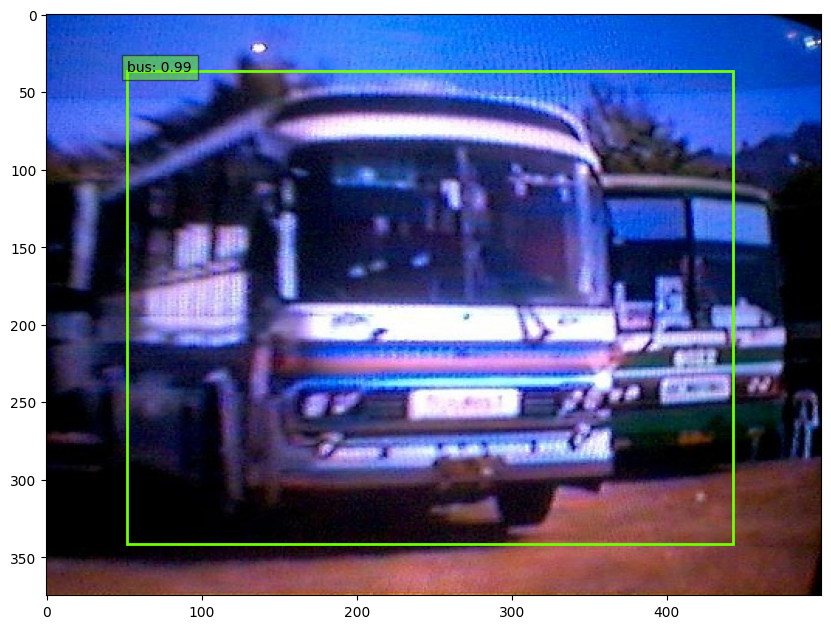

In [ ]:
img_path='./data/VOCdevkit/VOC2012/JPEGImages/2007_000768.jpg'
ssd.show(img_path,0.6)

In [10]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader
from torchvision import models
import xml.etree.ElementTree as ET
from tqdm import tqdm

In [ ]:
# yolo
# 1. 경로 설정
path='./data/VOCdevkit/VOC2012'
IMG_DIR=os.path.join(path,'JPEGImages')
ANN_DIR=os.path.join(path,'Annotations')
SET_DIR=os.path.join(path,'ImageSets','Main')
TRAIN_LIST=os.path.join(SET_DIR,'train.txt')
VAL_LIST=os.path.join(SET_DIR,'val.txt')

# 2. 클래스 정립
VOC_CLASSES=['aeroplane', 'bicycle', 'bird', 'boat',
'bottle', 'bus', 'car', 'cat', 'chair',
'cow', 'diningtable', 'dog', 'horse',
'motorbike', 'person', 'pottedplant',
'sheep', 'sofa', 'train', 'tvmonitor']
C=len(VOC_CLASSES)
S=7
B=2
IMG_SIZE=224
CELL=IMG_SIZE//S

def read_split_list(list_path):
    with open(list_path,'r') as f:
        ids=[line.strip() for line in f if line.strip()]
    return ids

def id_to_paths(img_id):
    return(
    os.path.join(IMG_DIR,f'{img_id}.jpg'),
    os.path.join(ANN_DIR,f'{img_id}.xml'))

# 3. 데이터 정리 (7X7 [tx,ty,tw,th,obj]+onehot(20))
def _get_text(node,tag,default=None):
    el=node.find(tag)
    return el.text if el is not None else default

def build_label_from_xml(xml_path,classes):
    label=np.zeros((S,S,5+len(classes)),dtype=np.float32)
    tree=ET.parse(xml_path)
    root=tree.getroot()
    size=root.find('size')
    W=float(_get_text(size,'width','1'))
    H=float(_get_text(size,'height','1'))
    for obj in root.findall('object'):
        c_name=_get_text(obj,'name','').lower()
        if c_name not in classes:
            continue
        cls_idx=classes.index(c_name)

        bnd=obj.find('bndbox')
        xmin=float(_get_text(bnd,'xmin','0'))
        ymin=float(_get_text(bnd,'ymin','0'))
        xmax=float(_get_text(bnd,'xmax','0'))
        ymax=float(_get_text(bnd,'ymax','0'))

        sx=IMG_SIZE/W
        sy=IMG_SIZE/H
        xmin*=sx
        ymin*=sy
        xmax*=sx
        ymax*=sy

        cx=(xmin+xmax)/2.0
        cy=(ymin+ymax)/2.0
        w=(xmax-xmin)
        h=(ymax-ymin)

        gx=int(cx//CELL)
        gy=int(cy//CELL)
        if not (0<=gx<S and 0<=gy<S):
            continue

        tx=(cx-gx*CELL)/CELL
        ty=(cy-gy*CELL)/CELL
        tw=w/IMG_SIZE
        th=h/IMG_SIZE

        label[gy,gx,0:5]=np.array([tx,ty,tw,th,1.0],dtype=np.float32)
        label[gy,gx,5+cls_idx]=1.0
    return label        

# 4. 데이터 로드
class VOCDatasetYOLOv1(Dataset):
    def __init__(self,id_list_path,classes):
        self.ids=read_split_list(id_list_path)
        self.classes=classes
    
    def __len__(self):
        return len(self.ids)
    
    def __getitem__(self,index):
        img_id=self.ids[index]
        img_p,ann_p=id_to_paths(img_id)
        img=cv2.imread(img_p)
        if img is None:
            raise RuntimeError(f'{img_p} 파일 없음')
        img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
        img=cv2.resize(img,(IMG_SIZE,IMG_SIZE)).astype(np.float32)/255.0
        img=np.transpose(img,(2,0,1))

        label=build_label_from_xml(ann_p,self.classes)
        return torch.from_numpy(img),torch.from_numpy(label)

tr_ds=VOCDatasetYOLOv1(TRAIN_LIST,VOC_CLASSES)
val_ds=VOCDatasetYOLOv1(VAL_LIST,VOC_CLASSES)

BATCH_SIZE=32
tr_ds_loader=DataLoader(tr_ds,batch_size=BATCH_SIZE,shuffle=True)
val_ds_loader=DataLoader(val_ds,batch_size=BATCH_SIZE,shuffle=False) 

# 5. 모델 설계(백본 모델 사용)
class YoloV1VGG16(nn.Module):
    def __init__(self,n_classes):
        super().__init__()
        self.S=S
        self.B=B
        self.C=n_classes

        vgg=models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        self.backbone=vgg.features
        for p in self.backbone.parameters():
            p.requires_grad=False
        self.head=nn.Sequential(
            nn.Conv2d(512,1024,3,1,1),
            nn.LeakyReLU(0.01,inplace=True),
            nn.Conv2d(1024,1024,3,1,1),
            nn.LeakyReLU(0.01,inplace=True),
            nn.MaxPool2d(2,2),
            nn.Conv2d(1024,1024,3,1,1),
            nn.LeakyReLU(0.01,inplace=True)
        )
        self.fc=nn.Sequential(
            nn.Flatten(),
            nn.Linear(3*3*1024,4096),
            nn.LeakyReLU(0.01,inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096,self.S*self.S*(10+self.C)), # 7X7(10+20)
        )
    
    def forward(self,x):
        x=self.backbone(x) # (N,512,7,7)
        x=self.head(x) # (N,1024,3,3)
        x=self.fc(x) # (N,S,S) -> (N,7*7*(10+20))
        x=x.view(-1,self.S,self.S,10+self.C) # (N,S,S,10+C)
        return x

# 6. loss 정립()
def _boxes_cell_to_abs(boxes,S,device):
    N=boxes.shape[0]
    yy,xx=torch.meshgrid(torch.arange(S,device=device),torch.arange(S,device=device),indexing='ij')
    yy=yy.view(1,S,S,1).float()
    xx=xx.view(1,S,S,1).float()

    # 바운딩 박스 중심 좌표 계산
    cx=(boxes[...,0:1]+xx)/S
    cy=(boxes[...,1:2]+yy)/S
    w=boxes[...,2:3]
    h=boxes[...,3:4]
    return torch.cat([cx,cy,w,h],dim=-1)

def bbox_iou_xyhw(b1,b2,eps=1e-7):
    cx1,cy1,w1,h1=b1.unbind(-1)
    cx2,cy2,w2,h2=b2.unbind(-1)

    x1_min=cx1-0.5*w1
    x1_max=cx1+0.5*w1
    y1_min=cy1-0.5*h1
    y1_max=cy1+0.5*h1
    
    x2_min=cx2-0.5*w2
    x2_max=cx2+0.5*w2
    y2_min=cy2-0.5*h2
    y2_max=cy2+0.5*h2

    # 바운딩 박스 좌상단, 우하단 좌표 계산
    inter_x_min=torch.maximum(x1_min,x2_min)
    inter_y_min=torch.maximum(y1_min,y2_min)
    inter_x_max=torch.minimum(x1_max,x2_max)
    inter_y_max=torch.minimum(y1_max,y2_max)

    inter_w=torch.clamp(inter_x_max-inter_x_min,min=0.0)
    inter_h=torch.clamp(inter_y_max-inter_y_min,min=0.0)
    inter=inter_w*inter_h

    # 최종 결과 도출 -> 합집합 - 교집합
    area1=torch.clamp(w1,min=0.0)*torch.clamp(h1,min=0.0)
    area2=torch.clamp(w2,min=0.0)*torch.clamp(h2,min=0.0)
    union=area1+area2-inter+eps
    return inter/union

class YoloV1loss(nn.Module):
    def __init__(self,S=7,B=2,C=20,lambda_coord=0.5,lambda_noobj=0.5):
        super().__init__()
        self.S=S
        self.B=B
        self.C=C
        self.lambda_coord=lambda_coord
        self.lambda_noobj=lambda_noobj

    def forward(self,pred,target):
        N=pred.shape[0]
        device=pred.device

        p_b1=pred[...,0:4] # 4가지 요소 확인 -> 박스1(tx,ty,tw,th)
        p_c1=pred[...,4:5] # 박스1 객체 신뢰도
        p_b2=pred[...,5:9] # 4가지 요소 확인 -> 박스2(tx,ty,tw,th)
        p_c2=pred[...,9:10] # 박스2 객체 신뢰도
        p_cls=pred[...,10:] # 클래스 확률(로짓->원핫, SSE)

        t_box=target[...,0:4] # 4가지 요소 확인 -> 타겟 박스(tx,ty,tw,th)
        t_obj=target[...,4:5] # 객체 유무
        t_cls=target[...,5:] # 클래스 원핫

        p_b1_abs=_boxes_cell_to_abs(p_b1,self.S,device)
        p_b2_abs=_boxes_cell_to_abs(p_b2,self.S,device)
        t_box_abs=_boxes_cell_to_abs(t_box,self.S,device)

        iou1=bbox_iou_xyhw(p_b1_abs,t_box_abs)
        iou2=bbox_iou_xyhw(p_b2_abs,t_box_abs)

        mask_b1=(iou1>iou2).float().unsqueeze(-1) # (N,S,S,1)
        mask_b2=1.0-mask_b1

        p_c_resp=mask_b1*p_c1+mask_b2*p_c2 # 책임 신뢰도(conf)
        p_c_nresp=mask_b1*p_c2+mask_b2*p_c1 # 비책임 신뢰도(conf)
        p_b_resp=mask_b1*p_b1+mask_b2*p_b2 # 책임 박스(셀 상대좌표)

        loc_loss=torch.sum(((t_box-p_b_resp)**2)*t_obj) # 1,2 loss(좌표 loss)
        obj_conf_loss=torch.sum(((p_c_resp-t_obj)**2)*t_obj) # 3 loss 객체 셀 신뢰도(conf(객체 loss))
        noobj_conf_loss=torch.sum((p_c_nresp**2)*(1.0-t_obj)) # 4 loss 배경 셀 신뢰도(conf(배경 loss))
        cls_loss=torch.sum(((t_cls-p_cls)**2)*t_obj) # 5 loss 클래스 -> 객체 셀만 적용(클래스 loss)
        total=self.lambda_coord*loc_loss+obj_conf_loss+self.lambda_noobj*noobj_conf_loss+cls_loss
        return total/max(N,1) # 배치 평균

# 7. 학습
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
m=YoloV1VGG16(n_classes=C).to(DEVICE)
criterion=YoloV1loss(S=S,B=B,C=C,lambda_coord=0.5,lambda_noobj=0.5)
opt=optim.SGD(m.parameters(),lr=0.001,weight_decay=5e-4)

def lr_lambda(epoch): # 0-74 : 변화 / 0.001-0.002 : 선형 / 75-104 : 유지 / 이후 : 0.0002 (감소)
    if epoch<75:
        return (0.001+0.001*(epoch/75.0))/0.001
    elif epoch<105:
        return 1.0*2.0
    else:
        return 0.1*2.0
scheduler=optim.lr_scheduler.LambdaLR(opt,lr_lambda=lr_lambda)
EPOCHS=120
SAVE_PATH='yolo_v1_voc2012_etree_ck.pt'
def train_one_epoch(m,loader,opt,scheduler,criterion,device):
    m.train()
    total=0.0
    for imgs,labels in tqdm(loader,desc='train'):
        imgs=imgs.to(device)
        labels=labels.to(device)

        opt.zero_grad()
        py=m(imgs)
        loss=criterion(py,labels)
        loss.backward()
        opt.step()

        total+=loss.item()*imgs.size(0)
    scheduler.step()
    return total/len(loader.dataset)

@torch.no_grad() # with 구문 대체
def eval_one_epoch(m,loader,criterion,device):
    m.eval()
    total=0.0
    for imgs,labels in tqdm(loader,desc='valid'):
        imgs=imgs.to(device)
        labels=labels.to(device)

        py=m(imgs)
        loss=criterion(py,labels)
        total+=loss.item()*imgs.size(0)
    return total/len(loader.dataset)
best_val=float('inf')
for epoch in range(EPOCHS):
    tr_loss=train_one_epoch(m,tr_ds_loader,opt,scheduler,criterion,DEVICE)
    val_loss=eval_one_epoch(m,val_ds_loader,criterion,DEVICE)
    print(f'[{epoch+1} / {EPOCHS}] tr_loss : {tr_loss:.3f} / val_loss : {val_loss:.3f} / lr : {scheduler.get_last_lr()[0]:.6f}')
    if val_loss<best_val:
        best_val=val_loss
        torch.save({'model':m.state_dict(),'classes':VOC_CLASSES},SAVE_PATH)
        print(f'save m : {SAVE_PATH} (val_loss : {best_val:.3f})')

valid: 100%|██████████| 182/182 [25:46<00:00,  8.50s/it]


[1 / 120] tr_loss : 5.468 / val_loss : 4.605 / lr : 0.001013
save m : yolo_v1_voc2012_etree_ck.pt (val_loss : 4.605)


valid: 100%|██████████| 182/182 [38:25<00:00, 12.67s/it]


[2 / 120] tr_loss : 4.832 / val_loss : 4.447 / lr : 0.001027
save m : yolo_v1_voc2012_etree_ck.pt (val_loss : 4.447)


train:  40%|████      | 72/179 [19:55<30:09, 16.91s/it]

In [ ]:
# 8. 예측
w=torch.load('yolo_v1_voc2012_etree_ck.pt',DEVICE)

In [ ]:
classes=w.get('classes',VOC_CLASSES)

In [ ]:
l_m=YoloV1VGG16(n_classes=len(classes)).to(DEVICE)

In [ ]:
l_m.load_state_dict(w['model'])

<All keys matched successfully>

In [ ]:
l_m.eval()
for imgs,labels in val_ds_loader:
    imgs=imgs.to(DEVICE)
    #labels=labels.to(DEVICE)
    py=l_m(imgs)
    print(imgs.size())
    break
py.shape

torch.Size([32, 3, 224, 224])


torch.Size([32, 7, 7, 30])

In [ ]:
# 후처리기
def decode_yolo_output(py,conf_thr=None,conf_obj_thr=0.1,score_thr=0.1,iou_thr=0.1,
                       max_box=20,topk=5,oj_img_size=(224,224),assume_sqrt_wh=False):
    if conf_thr is not None:
        if score_thr==0.1:
            score_thr=conf_thr
        if iou_thr==0.1:
            iou_thr=conf_thr
    ck_v=0
    S,B,C=7,2,py.shape[-1]-10
    cell=1.0/S
    out=py

    b1=out[...,0:4]
    c1=out[...,4:5]
    b2=out[...,5:9]
    c2=out[...,9:10]
    pcls=out[...,10:]

    conf1=torch.sigmoid(c1)
    conf2=torch.sigmoid(c2)
    use_b1=(conf1>=conf2).float()
    conf=use_b1*conf1+(1.0-use_b1)*b2
    cls=torch.softmax(pcls,dim=-1)
    bbox=use_b1*b1+(1.0-use_b1)*b2

    yy,xx=torch.meshgrid(torch.arange(S),torch.arange(S),indexing='ij')
    xx=xx.unsqueeze(-1).float().to(DEVICE)
    yy=yy.unsqueeze(-1).float().to(DEVICE)
    cx=(bbox[...,0:1]+xx)/S
    cy=(bbox[...,1:2]+yy)/S
    w_n=torch.clamp(bbox[...,2:3],0,1)
    h_n=torch.clamp(bbox[...,3:4],0,1)
    
    if assume_sqrt_wh:
        w_n=w_n**2
        w_h=w_h**2
    W,H=oj_img_size
    x1=(cx-0.5*w_n)*W
    x2=(cx+0.5*w_n)*W
    y1=(cx-0.5*h_n)*H
    y2=(cx+0.5*h_n)*H

    sc_all=(conf*cls).view(-1,C)
    best_sc,cls_ids=sc_all.max(dim=1)
    boxes=torch.stack([x1.view(-1),y1.view(-1),x2.view(-1),y2.view(-1)],1)

    m=best_sc>=score_thr # 점수 기준
    boxes=boxes[m]
    scores=best_sc[m]
    clses=cls_ids[m]

    # NMS : 클래스 무관
    def nms_xyxy(bxs,scs,thr):
        if bxs.numel()==0:
            return []
        idx=scs.argsort(descending=True)
        keep=[]
        while idx.numel()>0:
            i=idx[0]
            keep.append(i.item())
            if idx.numel()==1:
                break
            rest=idx[1:]
            br=bxs[rest]

            xx1=torch.maximum(bxs[i,0],br[:,0])
            xx2=torch.minimum(bxs[i,2],br[:,2])
            yy1=torch.minimum(bxs[i,1],br[:,1])
            yy2=torch.minimum(bxs[i,3],br[:,3])

            inter=(xx2-xx1).clamp(min=0)*(yy2-yy1).clamp(min=0)
            ai=(bxs[i,2]-bxs[i,0]).clamp(min=0)*(bxs[i,3]-bxs[i,1]).clamp(min=0)
            ar=(br[i,2]-br[i,0]).clamp(min=0)*(br[i,3]-br[i,1]).clamp(min=0)
            iou=inter/(ai+ar-inter+1e-7)
            idx=rest[iou<=thr]
        return keep
    if boxes.numel()>0:
        keep=nms_xyxy(boxes,scores,iou_thr)
        if keep:
            keep=torch.tensor(keep,device=boxes.device)
            boxes,scores,clses=boxes[keep],scores[keep],clses[keep]
    
    dets=[(float(b[0]),float(b[1]),float(b[2]),float(b[3]),float(s),int(c.item())) for b,s,c in zip(boxes,scores,clses)]
    if len(dets)==0 and topk>0 and boxes.numel()>0:
        ck_v=1
        topk=min(topk,boxes.shape[0])
        tk_sc,tk_idx=torch.topk(best_sc,k=topk)        
        for s,i in zip(tk_sc,tk_idx):
            dets.append([(float(boxes[0]),float(boxes[1]),float(boxes[2]),float(boxes[3]),float(s),int(clses.item()))])
    return dets,'임의 생성' if ck_v else dets

현재 작업 경로: c:\Users\ksa\Desktop\vs\pn\deep


In [ ]:
import cv2
img_path='./data/VOCdevkit/VOC2012/JPEGImages/2007_000768.jpg'

img=cv2.imread('path')
rgb_img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
x=cv2.resize(rgb_img,(224,224)).astype(np.float32)/255.0
x=torch.from_numpy(x.transpose(2,0,1))[None].to(DEVICE)
py=m(x)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
f,ax=plt.subplot(1,1,fisize=(10,10))
ax.imshow()
ax.axis('off')
out_data=decode_yolo_output(py,score_thr=0.1,iou_thr=0.1,max_box=20,topk=5,oj_img_size=(224,224))
if type(out_data)==list:
    dets=out_data
else:
    dets=out_data[0]
for (xa,ya,xb,yb,sc,ci) in dets:
    xa,ya,xb,yb=map(int,[xa,ya,xb,yb]) # 1회성 동작 -> int(xa),int(ya),int(xb),int(yb)
    ax.add_patch(Rectangle(xa,ya),xb-xa,yb-ya,fill=False,edgecolor='lime',linewidth=2)
    ax.text(xa,max(0,ya-4),f'{classes[ci]}:{sc:.3f}',fontsize=10,color="black",
            bbox=dict(fececolor='lime',alpha=0.9,edgecolor='none',pad=2))

In [4]:
from tqdm import tqdm
for i in tqdm(range(100000000),desc='for문 동작'):
    10+10
    

for문 동작:   0%|          | 0/100000000 [00:00<?, ?it/s]

for문 동작: 100%|██████████| 100000000/100000000 [00:18<00:00, 5347349.84it/s]


In [ ]:
import builtins
len(dir(builtins)),dir(builtins)

['ArithmeticError',
 'AssertionError',
 'AttributeError',
 'BaseException',
 'BaseExceptionGroup',
 'BlockingIOError',
 'BrokenPipeError',
 'BufferError',
 'BytesWarning',
 'ChildProcessError',
 'ConnectionAbortedError',
 'ConnectionError',
 'ConnectionRefusedError',
 'ConnectionResetError',
 'DeprecationWarning',
 'EOFError',
 'Ellipsis',
 'EncodingWarning',
 'EnvironmentError',
 'Exception',
 'ExceptionGroup',
 'False',
 'FileExistsError',
 'FileNotFoundError',
 'FloatingPointError',
 'FutureWarning',
 'GeneratorExit',
 'IOError',
 'ImportError',
 'ImportWarning',
 'IndentationError',
 'IndexError',
 'InterruptedError',
 'IsADirectoryError',
 'KeyError',
 'KeyboardInterrupt',
 'LookupError',
 'MemoryError',
 'ModuleNotFoundError',
 'NameError',
 'None',
 'NotADirectoryError',
 'NotImplemented',
 'NotImplementedError',
 'OSError',
 'OverflowError',
 'PendingDeprecationWarning',
 'PermissionError',
 'ProcessLookupError',
 'RecursionError',
 'ReferenceError',
 'ResourceWarning',
 'Runti